# Introduction:

# GRABMyoPC Dataset

The GRABMyoPC dataset is an electromyography (EMG) dataset designed for hand gesture recognition. 
It contains recordings collected from multiple participants across three recording sessions. 
Each participant performs multiple hand gestures, and every gesture is repeated several times. 
The dataset also includes participant information, gesture descriptions, device specifications, and electrode placement details.

# Import Libraries

In [40]:
import os
import glob
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from scipy.stats import skew, kurtosis

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#  Dataset Overview


In [41]:

DATASET = "/kaggle/input/datasets/raihanbd/grabmyopc"

# Hand Gesture Classes:

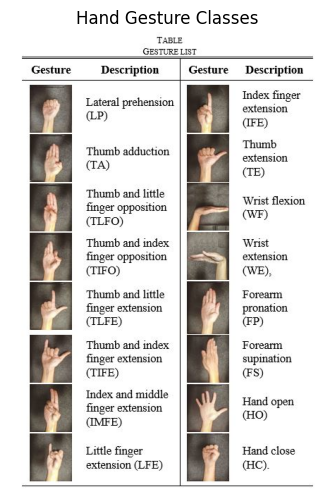

In [78]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(DATASET + "/GestureList.JPG")

plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis("off")
plt.title("Hand Gesture Classes")
plt.show()

# Count Sessions

In [42]:
sessions = sorted([
    d for d in os.listdir(DATASET)
    if d.startswith("Session")
])

print(sessions)
print("Total Sessions:", len(sessions))

['Session1', 'Session2', 'Session3']
Total Sessions: 3


# Count Participants

In [43]:
participants = set()

for file in hea_files:
    m = re.search(r'participant(\d+)', file)
    if m:
        participants.add(int(m.group(1)))

print("Total Participants:", len(participants))

Total Participants: 43


# Count Recordings 

In [44]:
hea_files = glob.glob(DATASET + "/**/*.hea", recursive=True)

print("Total Recordings:", len(hea_files))

Total Recordings: 15351


# Count Gestures 

In [45]:
gesture_count = {}

for file in hea_files:

    m = re.search(r'gesture(\d+)', file)

    if m:
        g = int(m.group(1))
        gesture_count[g] = gesture_count.get(g, 0) + 1

gesture_df = pd.DataFrame(
    gesture_count.items(),
    columns=["Gesture","Recordings"]
).sort_values("Gesture")

gesture_df

,Gesture,Recordings
13,1,903
3,2,903
12,3,903
1,4,903
9,5,903
8,6,903
0,7,903
7,8,903
2,9,903
16,10,903


# Count Trials

In [46]:
trial_count = {}

for file in hea_files:

    m = re.search(r'trial(\d+)', file)

    if m:
        t = int(m.group(1))
        trial_count[t] = trial_count.get(t,0)+1

trial_df = pd.DataFrame(
    trial_count.items(),
    columns=["Trial","Count"]
)

trial_df

,Trial,Count
0,2,2193
1,5,2193
2,1,2193
3,4,2193
4,6,2193
5,7,2193
6,3,2193


# Dataset Summary Table

In [47]:
summary = pd.DataFrame({

    "Property":[
        "Sessions",
        "Participants",
        "Gestures",
        "Trials",
        "Recordings"
    ],

    "Value":[
        len(sessions),
        len(participants),
        len(gesture_count),
        len(trial_count),
        len(hea_files)
    ]
})

summary

,Property,Value
0,Sessions,3
1,Participants,43
2,Gestures,17
3,Trials,7
4,Recordings,15351


# Subject Information

In [48]:
subject_info = pd.read_csv(
    DATASET + "/subject-info.csv"
)

subject_info.head()


,Sl,ID,Age,Sex,Forearm Length,Upper ring circumference,Wrist circumference
0,1,participant1,27.0,F,26.5,26.0,16.5
1,2,participant2,25.0,M,26.0,26.0,17.5
2,3,participant3,24.0,F,25.0,22.0,15.0
3,4,participant4,29.0,F,25.0,21.6,16.2
4,5,participant5,26.0,M,27.0,30.0,18.6


In [49]:
subject_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Sl                        45 non-null     object 
 1   ID                        43 non-null     object 
 2   Age                       45 non-null     float64
 3   Sex                       43 non-null     object 
 4   Forearm Length            45 non-null     float64
 5   Upper ring circumference  45 non-null     float64
 6   Wrist circumference       45 non-null     float64
dtypes: float64(4), object(3)
memory usage: 2.6+ KB


In [50]:
subject_info.describe(include="all")

,Sl,ID,Age,Sex,Forearm Length,Upper ring circumference,Wrist circumference
count,45,43,45.000000,43,45.000000,45.000000,45.000000
unique,45,43,NaN,2,NaN,NaN,NaN
top,1,participant1,NaN,M,NaN,NaN,NaN
freq,1,1,NaN,23,NaN,NaN,NaN
mean,NaN,NaN,25.872578,NaN,24.633289,23.619622,15.853400
std,NaN,NaN,4.490839,NaN,3.883669,3.941952,2.528405
min,NaN,NaN,2.871000,NaN,1.745000,2.278000,1.217000
25%,NaN,NaN,24.000000,NaN,24.000000,23.000000,15.500000
50%,NaN,NaN,26.000000,NaN,25.000000,24.000000,16.186000
75%,NaN,NaN,28.000000,NaN,26.500000,25.200000,16.800000


# Gesture Distribution

Each of the 17 gestures contains 903 recordings, indicating that the dataset is perfectly balanced across all gesture classes. A balanced dataset helps reduce classification bias during model training.

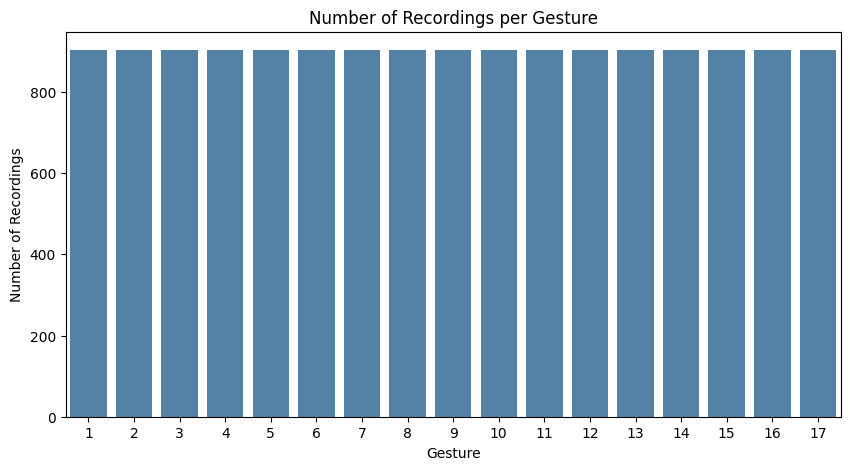

In [51]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Gesture",
    y="Recordings",
    data=gesture_df,
    color="steelblue"
)

plt.title("Number of Recordings per Gesture")
plt.xlabel("Gesture")
plt.ylabel("Number of Recordings")

plt.show()

# Trial Distribution

Every trial contains 2,193 recordings, showing that data collection was performed consistently across all seven trials.

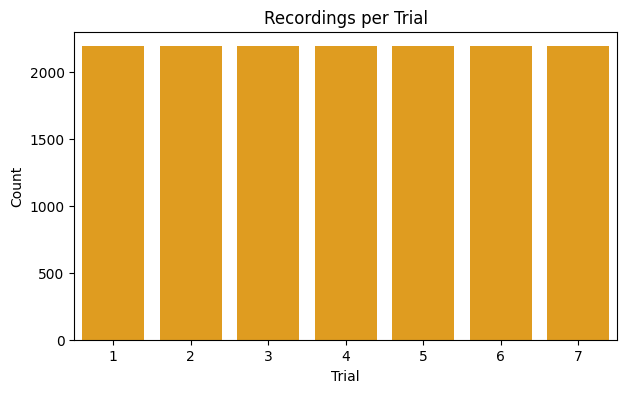

In [52]:
trial_df = trial_df.sort_values("Trial")

plt.figure(figsize=(7,4))

sns.barplot(
    x="Trial",
    y="Count",
    data=trial_df,
    color="orange"
)

plt.title("Recordings per Trial")
plt.xlabel("Trial")
plt.ylabel("Count")

plt.show()

# Gender Distribution 

The participant pool consists of 23 males (53.5%)
and 20 females (46.5%), indicating a nearly balanced gender distribution.

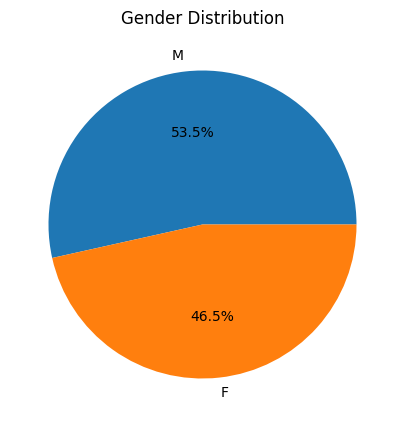

In [53]:
plt.figure(figsize=(5,5))

subject_info["Sex"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Gender Distribution")

plt.show()

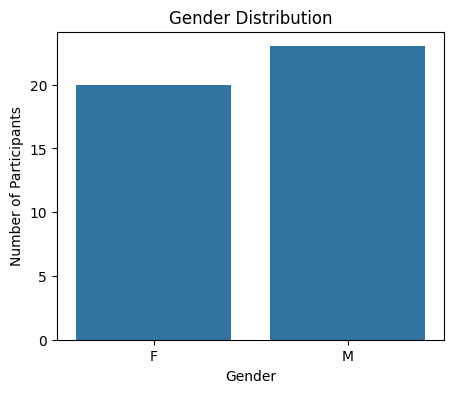

In [54]:
plt.figure(figsize=(5,4))

sns.countplot(data=subject_info, x="Sex")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Participants")

plt.show()

In [55]:
subject_info["Sex"].value_counts()

Sex
M    23
F    20
Name: count, dtype: int64

In [56]:
subject_info.sort_values("Age").head()

,Sl,ID,Age,Sex,Forearm Length,Upper ring circumference,Wrist circumference
44,SD,NaN,2.871,NaN,1.745,2.278,1.217
19,20,participant20,19.000,F,24.200,26.700,18.000
24,25,participant25,22.000,F,24.000,24.000,16.500
22,23,participant23,23.000,F,23.500,22.800,16.200
33,34,participant34,23.000,F,25.000,26.000,17.200


In [57]:
subject_info.sort_values("Wrist circumference").head()

,Sl,ID,Age,Sex,Forearm Length,Upper ring circumference,Wrist circumference
44,SD,NaN,2.871,NaN,1.745,2.278,1.217
5,6,participant6,26.000,F,23.000,21.000,13.900
28,29,participant29,32.000,F,24.000,20.200,14.000
11,12,participant12,29.000,F,23.000,19.000,14.000
38,39,participant39,24.000,F,21.800,20.000,14.000


🚨 The strange row is NOT a participant

Look at this row:

Sl	ID	Age	Sex	Forearm	Upper Ring	Wrist
SD	NaN	2.871	NaN	1.745	2.278	1.217

This is not a person's data.

It's the Standard Deviation (SD) row that was accidentally stored inside subject-info.csv.

That's why:

Sl = SD
ID = NaN
Sex = NaN

The numeric values (2.871, 1.745, etc.) are standard deviations, not ages or body measurements. So this row should not be included in your participant analysis.

Clean the data first

In [58]:
subject_info = subject_info[subject_info["ID"].notna()].copy()

subject_info.reset_index(drop=True, inplace=True)

subject_info.head()

,Sl,ID,Age,Sex,Forearm Length,Upper ring circumference,Wrist circumference
0,1,participant1,27.0,F,26.5,26.0,16.5
1,2,participant2,25.0,M,26.0,26.0,17.5
2,3,participant3,24.0,F,25.0,22.0,15.0
3,4,participant4,29.0,F,25.0,21.6,16.2
4,5,participant5,26.0,M,27.0,30.0,18.6


In [59]:
subject_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Sl                        43 non-null     object 
 1   ID                        43 non-null     object 
 2   Age                       43 non-null     float64
 3   Sex                       43 non-null     object 
 4   Forearm Length            43 non-null     float64
 5   Upper ring circumference  43 non-null     float64
 6   Wrist circumference       43 non-null     float64
dtypes: float64(4), object(3)
memory usage: 2.5+ KB


# Age Distribution

Looks good, but there is one issue.

See the small bar around age ≈ 3?

That is not a real age. In your statistics:

Minimum age = 2.871

Nobody in the dataset is 2.9 years old.

This is likely a data entry error or an incorrectly formatted value.

We should identify it.

Most participants are between 22 and 30 years of age, with one unusually low age value that appears to be an outlier or data-entry error.

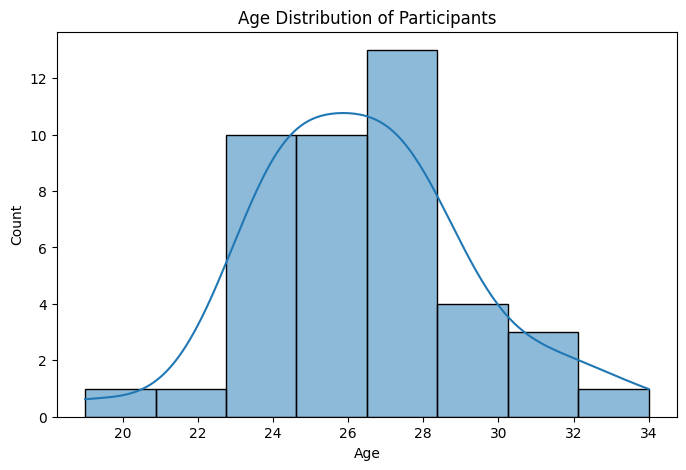

In [60]:
plt.figure(figsize=(8,5))

sns.histplot(
    subject_info["Age"],
    bins=8,
    kde=True
)

plt.title("Age Distribution of Participants")
plt.xlabel("Age")

plt.show()

# Wrist Circumference

Very nice.

Again, there is one strange value near 1.

Normal wrist circumference should be around 15–19 cm.

This suggests another outlier.

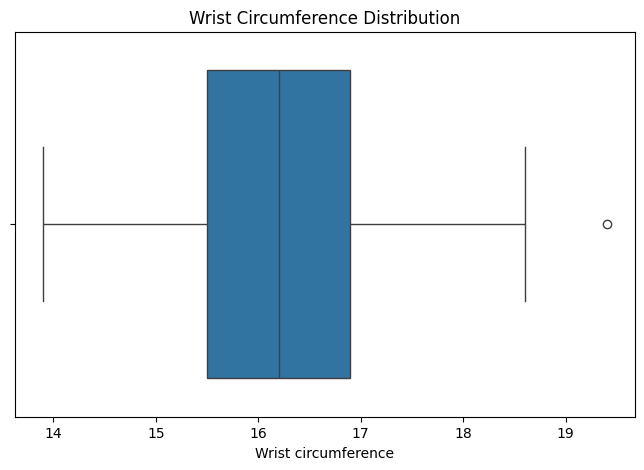

In [61]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=subject_info["Wrist circumference"]
)

plt.title("Wrist Circumference Distribution")

plt.show()

# Forearm Length

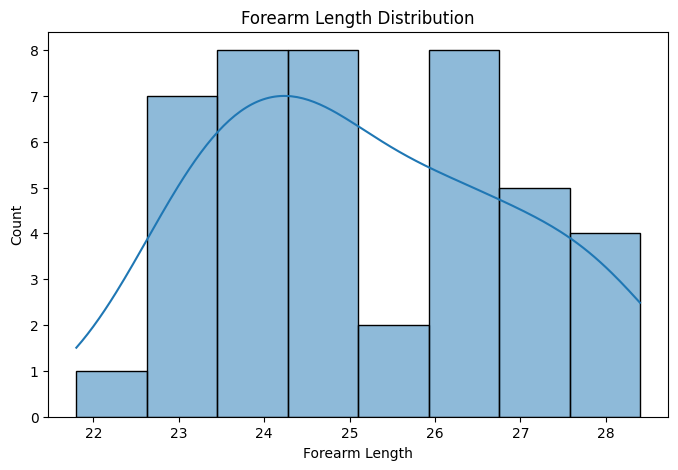

In [62]:
plt.figure(figsize=(8,5))
sns.histplot(subject_info["Forearm Length"], bins=8, kde=True)

plt.title("Forearm Length Distribution")
plt.show()

# Upper Ring Circumference

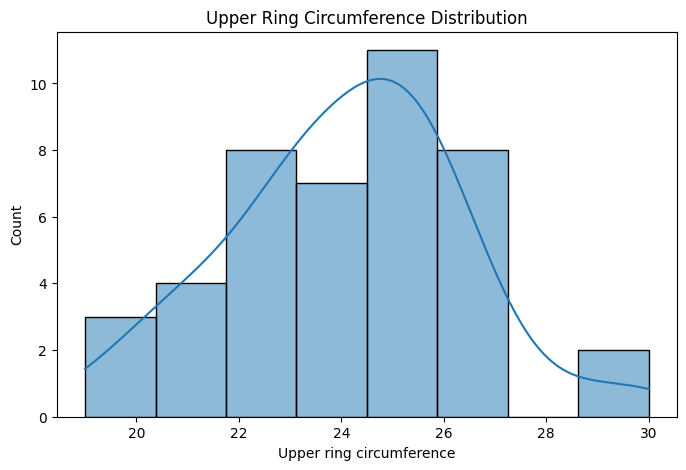

In [63]:
plt.figure(figsize=(8,5))
sns.histplot(subject_info["Upper ring circumference"], bins=8, kde=True)

plt.title("Upper Ring Circumference Distribution")
plt.show()

# Correlation Heatmap

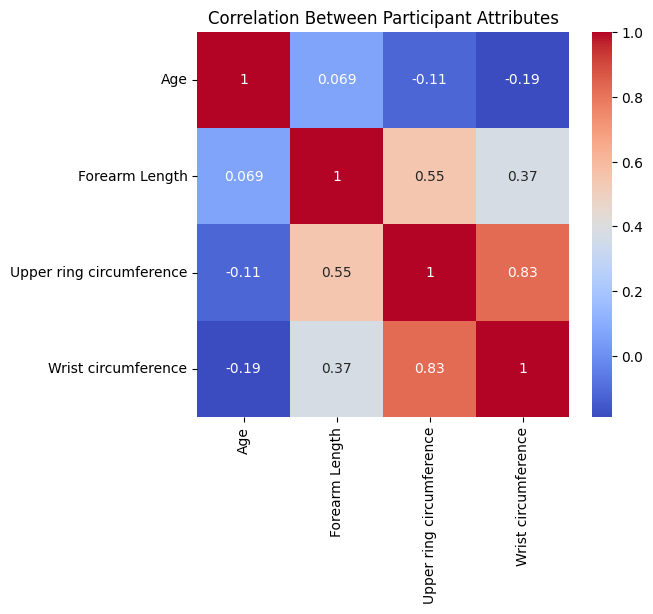

In [64]:
plt.figure(figsize=(6,5))

sns.heatmap(
    subject_info.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Participant Attributes")

plt.show()

# Analyze the Actual EMG recordings 
stored in the .hea and .dat files.

# Load an EMG Recording

In [65]:
!pip -q install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.3 MB/s eta 0:00:00


In [66]:
import wfdb

# Read One Recording

In [67]:
record_path = "/kaggle/input/datasets/raihanbd/grabmyopc/Session1/session1_participant1/session1_participant1_gesture1_trial1"

record = wfdb.rdrecord(record_path)

print(record)

# Basic Info

In [68]:
print("Sampling Frequency :", record.fs)

print("Signal Shape :", record.p_signal.shape)

print("Number of Channels :", len(record.sig_name))

print("Channel Names :")

print(record.sig_name)

Sampling Frequency : 2048
Signal Shape : (10240, 32)
Number of Channels : 32
Channel Names :
['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'U1', 'W1', 'W2', 'W3', 'W4', 'W5', 'W6', 'U2', 'U3', 'W7', 'W8', 'W9', 'W10', 'W11', 'W12', 'U4']


# Convert to DataFrame

Now every column is an EMG channel.

In [69]:
emg_df = pd.DataFrame(
    record.p_signal,
    columns=record.sig_name
)

emg_df.head()

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,...,W6,U2,U3,W7,W8,W9,W10,W11,W12,U4
0,-0.061532,-0.060511,-0.071205,-0.100274,-0.109246,-0.181119,-0.200781,-0.101178,-0.093508,-0.098052,...,0.020201,-0.006805,-0.005269,0.038960,0.055144,0.028680,-0.004255,0.019132,0.024891,-0.005122
1,-0.008153,-0.010117,-0.014876,-0.031756,0.011857,0.014340,-0.058956,-0.032768,-0.028832,-0.036216,...,0.028641,-0.005360,-0.003567,0.060238,0.079040,0.043158,-0.001968,0.021645,0.037256,-0.003871
2,0.016296,0.011263,0.014153,0.014917,0.100298,0.113098,0.048630,0.020172,0.002940,-0.009794,...,0.042727,-0.002255,0.000050,0.069348,0.093257,0.056523,0.003890,0.025789,0.042360,-0.001449
3,0.016287,0.008055,0.016694,0.032323,0.100898,0.085844,0.083983,0.037778,0.005684,-0.009767,...,0.038180,-0.002261,-0.000071,0.061171,0.091614,0.058421,0.004479,0.016028,0.031006,-0.002505
4,0.024458,0.018287,0.027319,0.044405,0.053518,0.032392,0.093212,0.048513,0.024495,0.016020,...,0.021443,-0.003120,-0.002286,0.055424,0.089250,0.052374,0.003085,0.000894,0.020955,-0.004205


# Basic Statistics

In [70]:
emg_df.describe().T

,count,mean,std,min,25%,50%,75%,max
F1,10240.0,-2.261783e-05,0.053253,-0.347754,-0.028228,0.003652,0.032243,0.270615
F2,10240.0,-3.352235e-05,0.053530,-0.340405,-0.028316,0.003662,0.032476,0.237133
F3,10240.0,-2.736585e-05,0.058536,-0.402345,-0.030838,0.004012,0.035835,0.238178
F4,10240.0,-3.369919e-05,0.070246,-0.509508,-0.036145,0.004395,0.042777,0.298357
F5,10240.0,-1.468425e-06,0.069140,-0.401121,-0.036140,0.004629,0.042806,0.254064
F6,10240.0,-1.675608e-05,0.100326,-0.615476,-0.049898,0.009703,0.060578,0.537549
F7,10240.0,-1.702610e-05,0.091742,-0.625139,-0.044376,0.008611,0.052798,0.498958
F8,10240.0,-1.428172e-05,0.060952,-0.424145,-0.030439,0.004784,0.036173,0.297422
F9,10240.0,-2.007265e-05,0.056239,-0.391066,-0.029750,0.004185,0.033952,0.248977
F10,10240.0,-2.701810e-05,0.056727,-0.373540,-0.030137,0.004166,0.034174,0.229129


# Missing Val

In [71]:
emg_df.isnull().sum()

F1     0
F2     0
F3     0
F4     0
F5     0
F6     0
F7     0
F8     0
F9     0
F10    0
F11    0
F12    0
F13    0
F14    0
F15    0
F16    0
U1     0
W1     0
W2     0
W3     0
W4     0
W5     0
W6     0
U2     0
U3     0
W7     0
W8     0
W9     0
W10    0
W11    0
W12    0
U4     0
dtype: int64

# Duplicate Rows

In [72]:
print("Duplicate rows :", emg_df.duplicated().sum())

Duplicate rows : 0


# Plot EMG Signal

Let's visualize the first 1000 samples.

The EMG signal fluctuates rapidly around zero, showing the electrical activity generated during muscle contraction. The waveform exhibits high-frequency variations, which are typical characteristics of EMG signals.

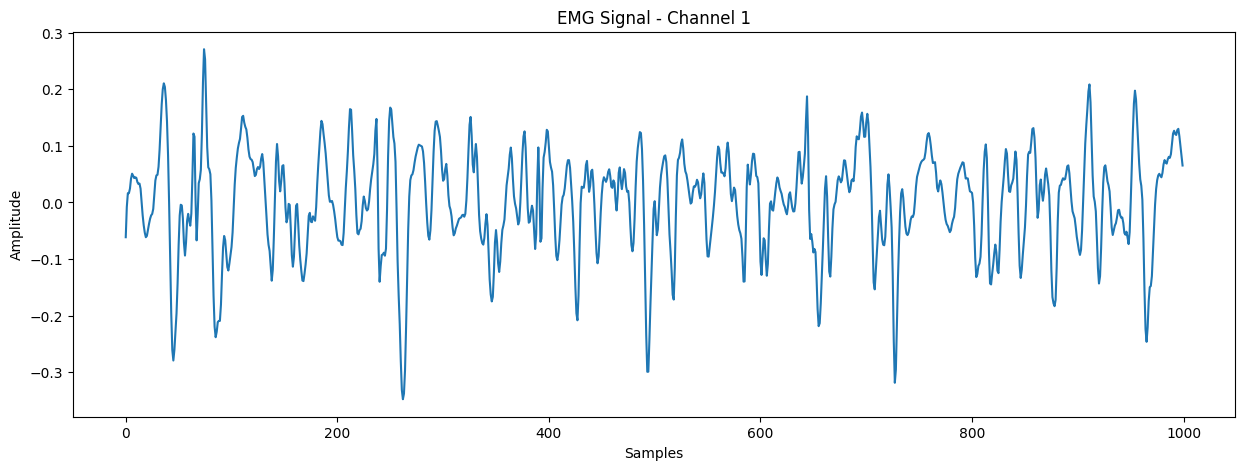

In [73]:
plt.figure(figsize=(15,5))

plt.plot(emg_df.iloc[:1000,0])

plt.title("EMG Signal - Channel 1")

plt.xlabel("Samples")

plt.ylabel("Amplitude")

plt.show()

# Histogram

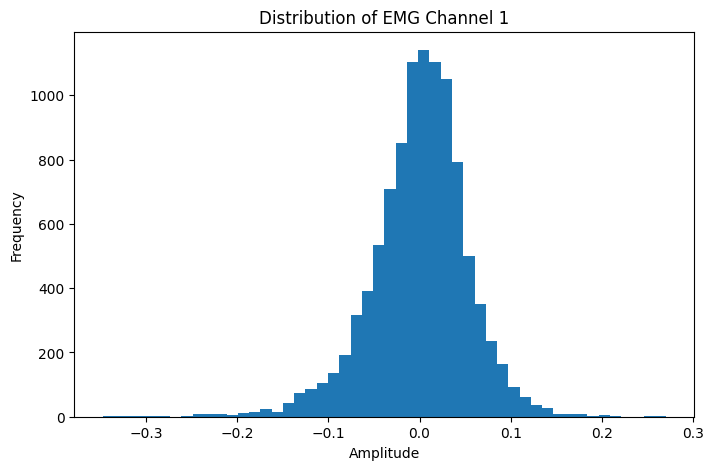

In [74]:
plt.figure(figsize=(8,5))

plt.hist(
    emg_df.iloc[:,0],
    bins=50
)

plt.title("Distribution of EMG Channel 1")

plt.xlabel("Amplitude")

plt.ylabel("Frequency")

plt.show()

# Boxplot

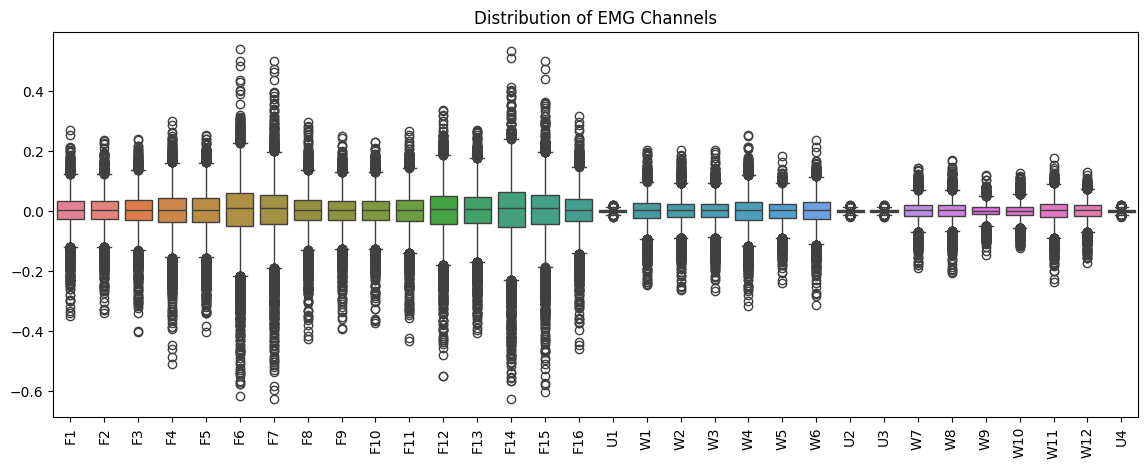

In [75]:
plt.figure(figsize=(14,5))

sns.boxplot(data=emg_df)

plt.title("Distribution of EMG Channels")

plt.xticks(rotation=90)

plt.show()

# Correlation Heatmap

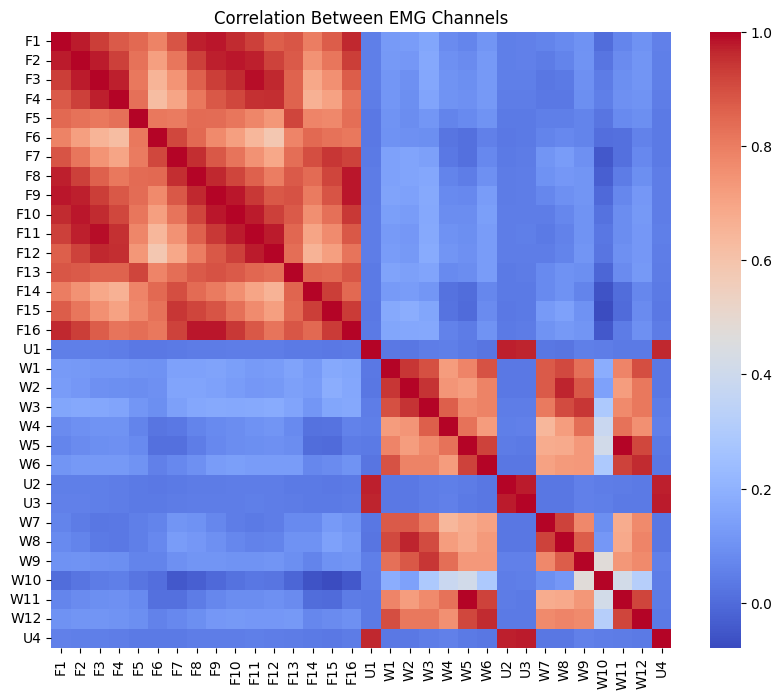

In [76]:
plt.figure(figsize=(10,8))

sns.heatmap(
    emg_df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Between EMG Channels")

plt.show()

# PCA

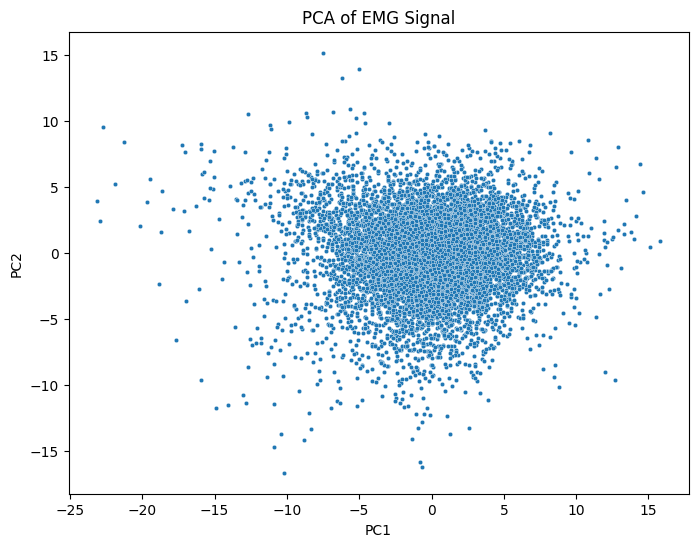

In [77]:
scaler = StandardScaler()

scaled = scaler.fit_transform(emg_df)

pca = PCA(n_components=2)

principal = pca.fit_transform(scaled)

pca_df = pd.DataFrame(
    principal,
    columns=["PC1","PC2"]
)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    data=pca_df,
    s=10
)

plt.title("PCA of EMG Signal")

plt.show()

# Conclusion

The exploratory data analysis of the GRABMyoPC dataset demonstrates that it is a well-structured and balanced dataset for hand gesture recognition. 


The dataset consists of 3 recording sessions, 43 participants, 17 gesture classes and 7 trials per gesture, resulting in 15,351 recordings. 

Participant demographics and physical measurements show consistent distributions with only minor variations. 


The EMG recordings contain 32 channels sampled at 2048 Hz, 
with no missing values or duplicate samples. 


Signal visualizations, descriptive statistics, correlation analysis, and PCA indicate high-quality EMG data suitable for machine learning and deep learning applications.